In [1]:
import re
import numpy as np
import pandas as pd
import itertools
from tqdm.auto import tqdm


import matplotlib.pyplot as plt


from bert_score import score
import pymorphy3
from rapidfuzz.distance import Levenshtein
from sacrebleu.metrics import BLEU, CHRF


import warnings
import logging
from transformers import logging as hf_logging

warnings.filterwarnings("ignore")

hf_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("bert_score").setLevel(logging.ERROR)

In [2]:
files = {
    0.0: "c2_generated_llama3_temp_0_0.csv",
    0.1: "c2_generated_llama3_temp_0_1.csv",
    0.2: "c2_generated_llama3_temp_0_2.csv",
    0.3: "c2_generated_llama3_temp_0_3.csv",
    0.4: "c2_generated_llama3_temp_0_4.csv",
    0.5: "c2_generated_llama3_temp_0_5.csv",
    0.6: "c2_generated_llama3_temp_0_6.csv",
    0.7: "c2_generated_llama3_temp_0_7.csv",
    0.8: "c2_generated_llama3_temp_0_8.csv",
    0.9: "c2_generated_llama3_temp_0_9.csv",
    1.0: "c2_generated_llama3_temp_1_0.csv",
    1.1: "c2_generated_llama3_temp_1_1.csv",
    1.2: "c2_generated_llama3_temp_1_2.csv",
    1.3: "c2_generated_llama3_temp_1_3.csv",
    1.4: "c2_generated_llama3_temp_1_4.csv",
    1.5: "c2_generated_llama3_temp_1_5.csv",
}

# Вспомогательные функции подсчета метрик

In [3]:
morph = pymorphy3.MorphAnalyzer()

def tokenize_words(text):
    text = str(text).lower()
    return re.findall(r"[а-яёa-z]+", text)


def lemmatize_text(text):
    words = tokenize_words(text)
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return lemmas

In [4]:
bleu_metric = BLEU(effective_order=True)
chrf_metric = CHRF()


def jaccard_similarity_lemmas(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas and not aug_lemmas:
        return 1.0

    if not orig_lemmas or not aug_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas | aug_lemmas)


def common_words_ratio(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas)


def normalized_levenshtein_distance(original, augmented):
    original = str(original)
    augmented = str(augmented)

    max_len = max(len(original), len(augmented))

    if max_len == 0:
        return 0.0

    distance = Levenshtein.distance(original, augmented)
    return distance / max_len


def normalized_levenshtein_similarity(original, augmented):
    return 1 - normalized_levenshtein_distance(original, augmented)

In [5]:
def lcs_length(x, y):
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if x[i] == y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    return dp[m][n]


def rouge_l_f1(original, augmented):
    orig_tokens = tokenize_words(original)
    aug_tokens = tokenize_words(augmented)

    if not orig_tokens or not aug_tokens:
        return 0.0

    lcs = lcs_length(orig_tokens, aug_tokens)

    precision = lcs / len(aug_tokens)
    recall = lcs / len(orig_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [6]:
def bleu_score(original, augmented):
    score = bleu_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100


def chrf_score(original, augmented):
    score = chrf_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100

# Сравнение аугментированных текстов внутри одной температуры

In [7]:
def calculate_pairwise_generated_metrics(text_1, text_2):
    common_ratio_1 = common_words_ratio(text_1, text_2)
    common_ratio_2 = common_words_ratio(text_2, text_1)

    bleu_1 = bleu_score(text_1, text_2)
    bleu_2 = bleu_score(text_2, text_1)

    chrf_1 = chrf_score(text_1, text_2)
    chrf_2 = chrf_score(text_2, text_1)

    return {
        "jaccard_lemmas": jaccard_similarity_lemmas(text_1, text_2),
        "common_words_ratio": (common_ratio_1 + common_ratio_2) / 2,
        "levenshtein_distance": normalized_levenshtein_distance(text_1, text_2),
        "levenshtein_similarity": normalized_levenshtein_similarity(text_1, text_2),
        "rouge_l": rouge_l_f1(text_1, text_2),
        "bleu": (bleu_1 + bleu_2) / 2,
        "chrf": (chrf_1 + chrf_2) / 2,
    }

In [8]:
all_pairwise_rows = []

for temp, path in files.items():
    df = pd.read_csv(path)

    generated_texts = df['generated-text'].astype(str).tolist()

    pairs = list(itertools.combinations(generated_texts, 2))

    print(f"Температура {temp}: {len(generated_texts)} текстов, {len(pairs)} пар")

    for text_1, text_2 in tqdm(pairs, desc=f"Temp {temp}", total=len(pairs)):
        metrics = calculate_pairwise_generated_metrics(text_1, text_2)

        metrics["temperature"] = temp
        all_pairwise_rows.append(metrics)

pairwise_metrics_df = pd.DataFrame(all_pairwise_rows)

Температура 0.0: 120 текстов, 7140 пар


Temp 0.0:   0%|          | 0/7140 [00:00<?, ?it/s]

Температура 0.1: 120 текстов, 7140 пар


Temp 0.1:   0%|          | 0/7140 [00:00<?, ?it/s]

Температура 0.2: 120 текстов, 7140 пар


...

Temp 1.3:   0%|          | 0/7140 [00:00<?, ?it/s]

Температура 1.4: 120 текстов, 7140 пар


Temp 1.4:   0%|          | 0/7140 [00:00<?, ?it/s]

Температура 1.5: 120 текстов, 7140 пар


Temp 1.5:   0%|          | 0/7140 [00:00<?, ?it/s]

In [9]:
pairwise_metrics_df

,jaccard_lemmas,common_words_ratio,levenshtein_distance,levenshtein_similarity,rouge_l,bleu,chrf,temperature
0,0.258065,0.411338,0.727979,0.272021,0.202247,0.057935,0.447871,0.0
1,0.258065,0.411338,0.727979,0.272021,0.202247,0.057935,0.447871,0.0
2,0.258065,0.411338,0.727979,0.272021,0.202247,0.057935,0.447871,0.0
3,0.258065,0.411338,0.727979,0.272021,0.202247,0.057935,0.447871,0.0
4,0.258065,0.411338,0.727979,0.272021,0.202247,0.057935,0.447871,0.0
...,...,...,...,...,...,...,...,...
114235,0.051282,0.098086,0.819477,0.180523,0.042553,0.010749,0.302128,1.5
114236,0.060976,0.114958,0.788599,0.211401,0.063830,0.010748,0.304658,1.5
114237,0.048387,0.095029,0.771971,0.228029,0.053333,0.015707,0.218135,1.5
114238,0.060606,0.120586,0.760494,0.239506,0.053333,0.015608,0.255324,1.5


In [10]:
metric_columns = [
    "jaccard_lemmas",
    "common_words_ratio",
    "levenshtein_distance",
    "levenshtein_similarity",
    "rouge_l",
    "bleu",
    "chrf",
]

pairwise_results_df = (
    pairwise_metrics_df
    .groupby("temperature")[metric_columns]
    .agg(["mean", "std", "min", "max"])
)

In [11]:
pairwise_results_df_flat = pairwise_results_df.copy()

pairwise_results_df_flat.columns = [
    f"{metric}_{stat}"
    for metric, stat in pairwise_results_df_flat.columns
]

pairwise_results_df_flat = pairwise_results_df_flat.reset_index()

In [12]:
pairwise_results_df['jaccard_lemmas']

,mean,std,min,max
temperature,,,,
0.0,0.987634,0.094989,0.258065,1.000000
0.1,0.219038,0.172070,0.038961,1.000000
0.2,0.149600,0.094967,0.000000,1.000000
0.3,0.126321,0.060535,0.012346,0.711111
0.4,0.121517,0.053611,0.013158,0.562500
0.5,0.109758,0.050371,0.011765,0.659091
0.6,0.106569,0.046697,0.000000,0.368421
0.7,0.093246,0.041390,0.000000,0.328125
0.8,0.090959,0.038064,0.000000,0.271186


In [13]:
pairwise_results_df['common_words_ratio']

,mean,std,min,max
temperature,,,,
0.0,0.990189,0.075365,0.411338,1.000000
0.1,0.334215,0.185207,0.075047,1.000000
0.2,0.251088,0.122024,0.000000,1.000000
0.3,0.220489,0.089034,0.024405,0.832432
0.4,0.213890,0.081644,0.026084,0.720128
0.5,0.195370,0.078613,0.023575,0.794670
0.6,0.190939,0.074174,0.000000,0.541667
0.7,0.169118,0.067731,0.000000,0.494734
0.8,0.165726,0.063189,0.000000,0.426743


In [14]:
pairwise_results_df['levenshtein_distance']

,mean,std,min,max
temperature,,,,
0.0,0.012133,0.093202,0.000000,0.727979
0.1,0.691055,0.169095,0.000000,0.840108
0.2,0.755201,0.095939,0.000000,0.873995
0.3,0.771641,0.056112,0.174807,0.859890
0.4,0.775541,0.040703,0.400000,0.858191
0.5,0.780814,0.033800,0.269634,0.856757
0.6,0.779583,0.030264,0.487981,0.864796
0.7,0.786086,0.027042,0.640884,0.863889
0.8,0.784425,0.027161,0.622739,0.863158


In [15]:
pairwise_results_df['levenshtein_similarity']

,mean,std,min,max
temperature,,,,
0.0,0.987867,0.093202,0.272021,1.000000
0.1,0.308945,0.169095,0.159892,1.000000
0.2,0.244799,0.095939,0.126005,1.000000
0.3,0.228359,0.056112,0.140110,0.825193
0.4,0.224459,0.040703,0.141809,0.600000
0.5,0.219186,0.033800,0.143243,0.730366
0.6,0.220417,0.030264,0.135204,0.512019
0.7,0.213914,0.027042,0.136111,0.359116
0.8,0.215575,0.027161,0.136842,0.377261


In [16]:
pairwise_results_df['rouge_l']

,mean,std,min,max
temperature,,,,
0.0,0.986704,0.102135,0.202247,1.000000
0.1,0.230205,0.201207,0.043956,1.000000
0.2,0.148088,0.110175,0.000000,1.000000
0.3,0.117221,0.064788,0.000000,0.780488
0.4,0.106823,0.049025,0.000000,0.586667
0.5,0.097563,0.042032,0.000000,0.716049
0.6,0.091840,0.037534,0.000000,0.469136
0.7,0.085852,0.034369,0.000000,0.300000
0.8,0.083563,0.033165,0.000000,0.303797


In [17]:
pairwise_results_df['bleu']

,mean,std,min,max
temperature,,,,
0.0,0.984299,0.120611,0.057935,1.000000
0.1,0.131470,0.203533,0.011158,1.000000
0.2,0.060784,0.102939,0.008231,1.000000
0.3,0.036817,0.048410,0.008084,0.735706
0.4,0.029682,0.030693,0.007951,0.469557
0.5,0.026423,0.023178,0.008038,0.602435
0.6,0.024797,0.018269,0.007112,0.374213
0.7,0.022844,0.014813,0.006288,0.151036
0.8,0.021527,0.014488,0.008494,0.168167


In [18]:
pairwise_results_df['chrf']

,mean,std,min,max
temperature,,,,
0.0,0.990798,0.070688,0.447871,1.000000
0.1,0.413815,0.145891,0.237888,1.000000
0.2,0.349315,0.089865,0.208594,1.000000
0.3,0.320700,0.058091,0.204608,0.841435
0.4,0.316643,0.049578,0.205239,0.669062
0.5,0.309846,0.041944,0.205413,0.776553
0.6,0.306515,0.040537,0.206051,0.575464
0.7,0.299306,0.034201,0.191830,0.474804
0.8,0.295662,0.032391,0.193380,0.453328


In [19]:
def plot_pairwise_metric(results_df, metric_name, title, ylabel):
    plt.figure(figsize=(8, 5))

    plt.plot(
        results_df["temperature"],
        results_df[f"{metric_name}_mean"],
        marker="o"
    )

    plt.xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
    plt.xlabel("Температура генерации")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()

    plt.show()

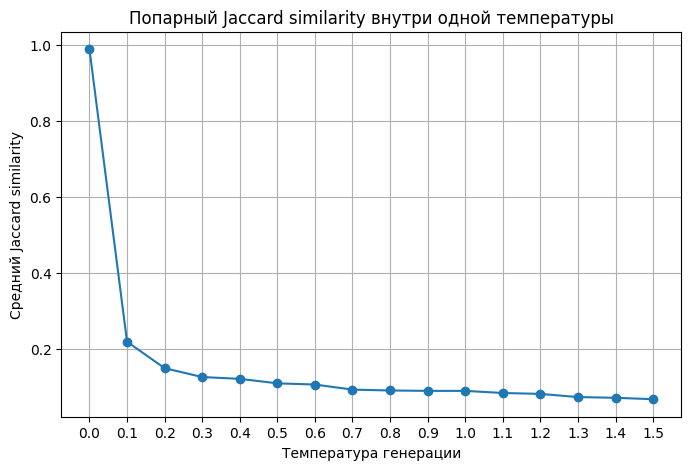

In [20]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "jaccard_lemmas",
    "Попарный Jaccard similarity внутри одной температуры",
    "Средний Jaccard similarity"
)

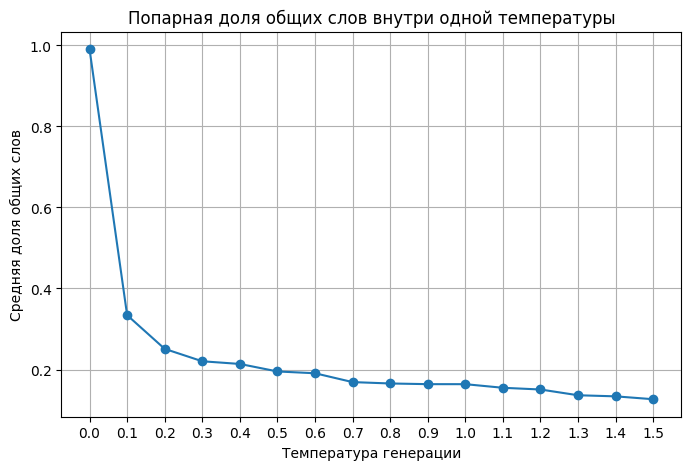

In [21]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "common_words_ratio",
    "Попарная доля общих слов внутри одной температуры",
    "Средняя доля общих слов"
)

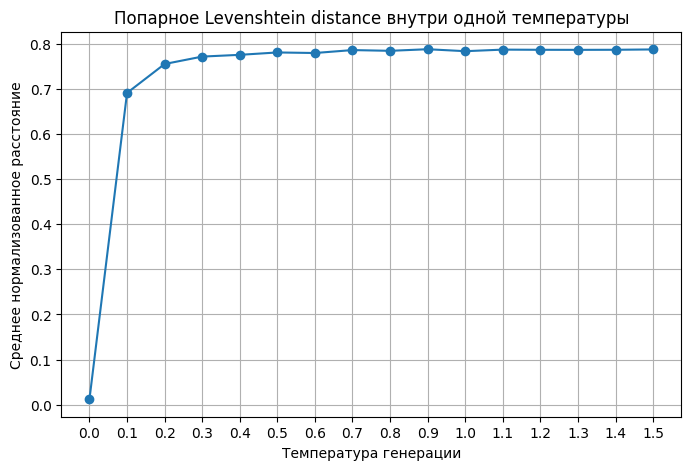

In [22]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "levenshtein_distance",
    "Попарное Levenshtein distance внутри одной температуры",
    "Среднее нормализованное расстояние"
)

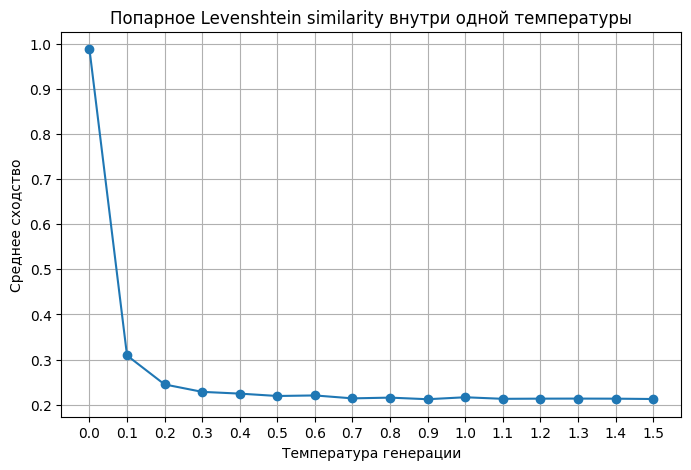

In [23]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "levenshtein_similarity",
    "Попарное Levenshtein similarity внутри одной температуры",
    "Среднее сходство"
)

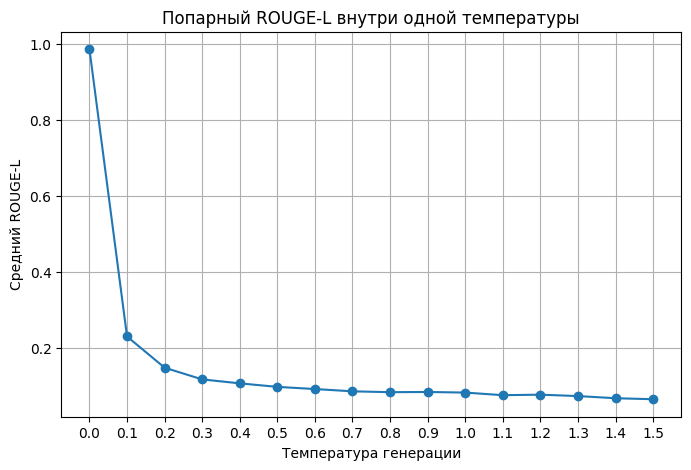

In [24]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "rouge_l",
    "Попарный ROUGE-L внутри одной температуры",
    "Средний ROUGE-L"
)

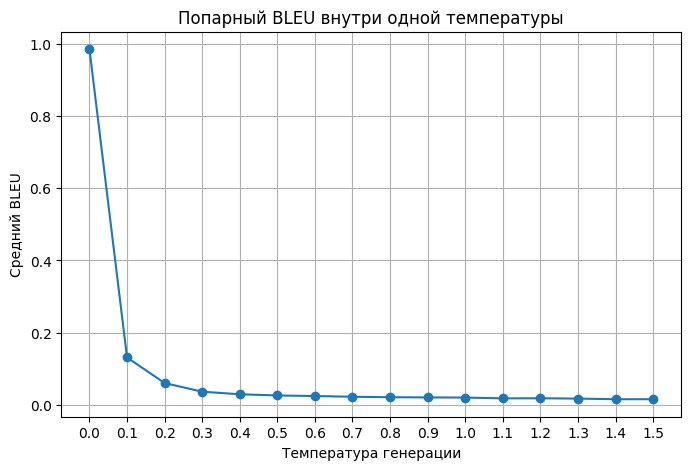

In [25]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "bleu",
    "Попарный BLEU внутри одной температуры",
    "Средний BLEU"
)

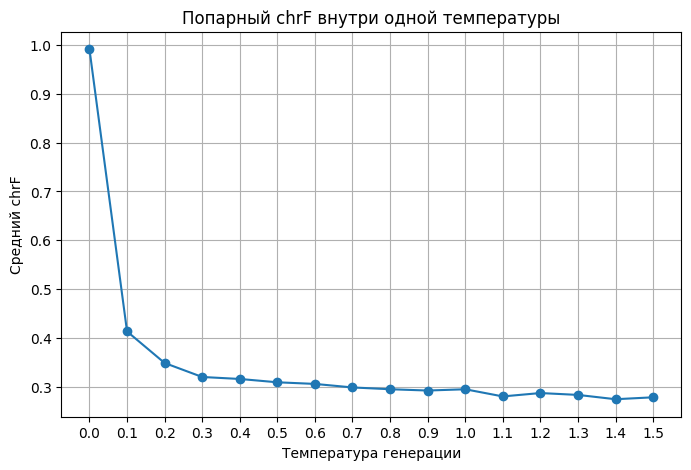

In [26]:
plot_pairwise_metric(
    pairwise_results_df_flat,
    "chrf",
    "Попарный chrF внутри одной температуры",
    "Средний chrF"
)